# 1. Perkenalan Dataset

**Nama:** ASEP HARYANA SAPUTRA  
**Dataset:** Poker Hand - UCI Machine Learning Repository  
**URL Sumber:** [UCI Poker Hand](https://archive.ics.uci.edu/dataset/158/poker+hand)

**Deskripsi Dataset:**
Dataset Poker Hand terdiri dari 1.025.010 instance dengan 10 fitur input dan 1 label kelas (0–9).
Setiap instance merepresentasikan 5 kartu poker (suit dan rank) dan tangan poker yang terbentuk.
Tantangan utama: **class imbalance ekstrem**—kelas 0 (Nothing) sangat dominan, sementara kelas langka seperti Straight Flush dan Royal Flush hanya muncul sedikit.

**Detail Fitur:**
- S1–S5: Suit kartu (1: Hearts, 2: Spades, 3: Diamonds, 4: Clubs)
- C1–C5: Rank kartu (1: Ace, 2–10, 11: Jack, 12: Queen, 13: King)
- CLASS: Tangan poker (0: Nothing, 1: One Pair, 2: Two Pairs, 3: Three of a Kind, 4: Straight, 5: Flush, 6: Full House, 7: Four of a Kind, 8: Straight Flush, 9: Royal Flush)

# 2. Import Library

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

from imblearn.over_sampling import SMOTE
from collections import Counter

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
print('Libraries loaded successfully.')

Libraries loaded successfully.


# 3. Memuat Dataset

In [2]:
# Column definitions berdasarkan poker-hand.names
COLUMNS = [
    'S1', 'C1',
    'S2', 'C2',
    'S3', 'C3',
    'S4', 'C4',
    'S5', 'C5',
    'CLASS'
]

CLASS_NAMES = {
    0: 'Nothing',
    1: 'One Pair',
    2: 'Two Pairs',
    3: 'Three of a Kind',
    4: 'Straight',
    5: 'Flush',
    6: 'Full House',
    7: 'Four of a Kind',
    8: 'Straight Flush',
    9: 'Royal Flush'
}

RAW_DIR = './pokerhand_raw'  # Pastikan direktori ini berisi file dataset

# Load training set (25.010 baris)
df_train = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-training-true.data'),
    header=None,
    names=COLUMNS
)

# Load testing set (1.000.000 baris) — untuk evaluasi final
df_test = pd.read_csv(
    os.path.join(RAW_DIR, 'poker-hand-testing.data'),
    header=None,
    names=COLUMNS
)

print(f'Training shape: {df_train.shape}')
print(f'Testing shape : {df_test.shape}')

Training shape: (25010, 11)
Testing shape : (1000000, 11)


# 4. Exploratory Data Analysis (EDA)

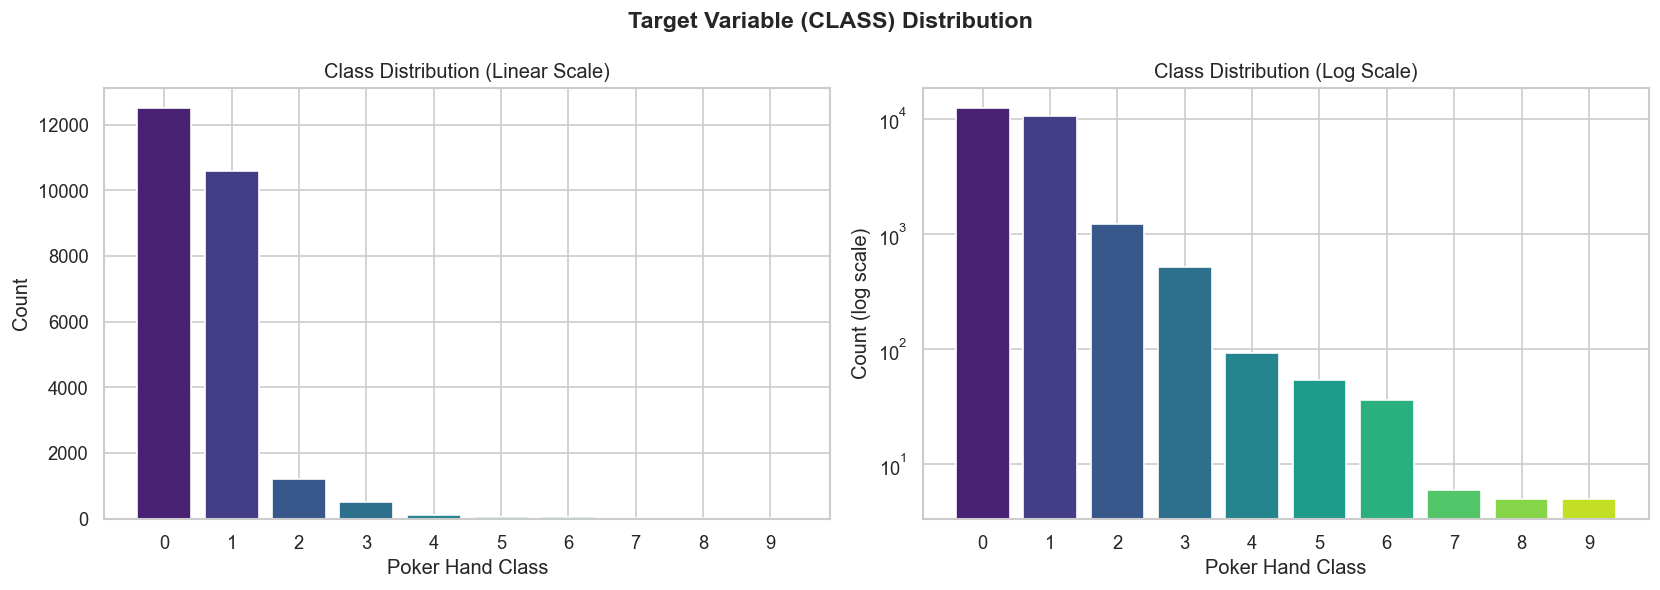


Class counts:
  Class 0 (Nothing): 12493 (49.9520%)
  Class 1 (One Pair): 10599 (42.3790%)
  Class 2 (Two Pairs): 1206 (4.8221%)
  Class 3 (Three of a Kind): 513 (2.0512%)
  Class 4 (Straight): 93 (0.3719%)
  Class 5 (Flush): 54 (0.2159%)
  Class 6 (Full House): 36 (0.1439%)
  Class 7 (Four of a Kind): 6 (0.0240%)
  Class 8 (Straight Flush): 5 (0.0200%)
  Class 9 (Royal Flush): 5 (0.0200%)


In [3]:
# ============================
# 4.1 Distribusi Target (Class)
# ============================
class_counts = df_train['CLASS'].value_counts().sort_index()
class_labels = [f'{k}: {CLASS_NAMES[k]}' for k in class_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Linear scale
axes[0].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[0].set_xlabel('Poker Hand Class')
axes[0].set_ylabel('Count')
axes[0].set_title('Class Distribution (Linear Scale)')
axes[0].set_xticks(range(10))

# Log scale — untuk melihat kelas minoritas
axes[1].bar(class_counts.index, class_counts.values, color=sns.color_palette('viridis', 10))
axes[1].set_yscale('log')
axes[1].set_xlabel('Poker Hand Class')
axes[1].set_ylabel('Count (log scale)')
axes[1].set_title('Class Distribution (Log Scale)')
axes[1].set_xticks(range(10))

plt.suptitle('Target Variable (CLASS) Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nClass counts:')
for k, v in class_counts.items():
    print(f'  Class {k} ({CLASS_NAMES[k]}): {v} ({v/len(df_train)*100:.4f}%)')

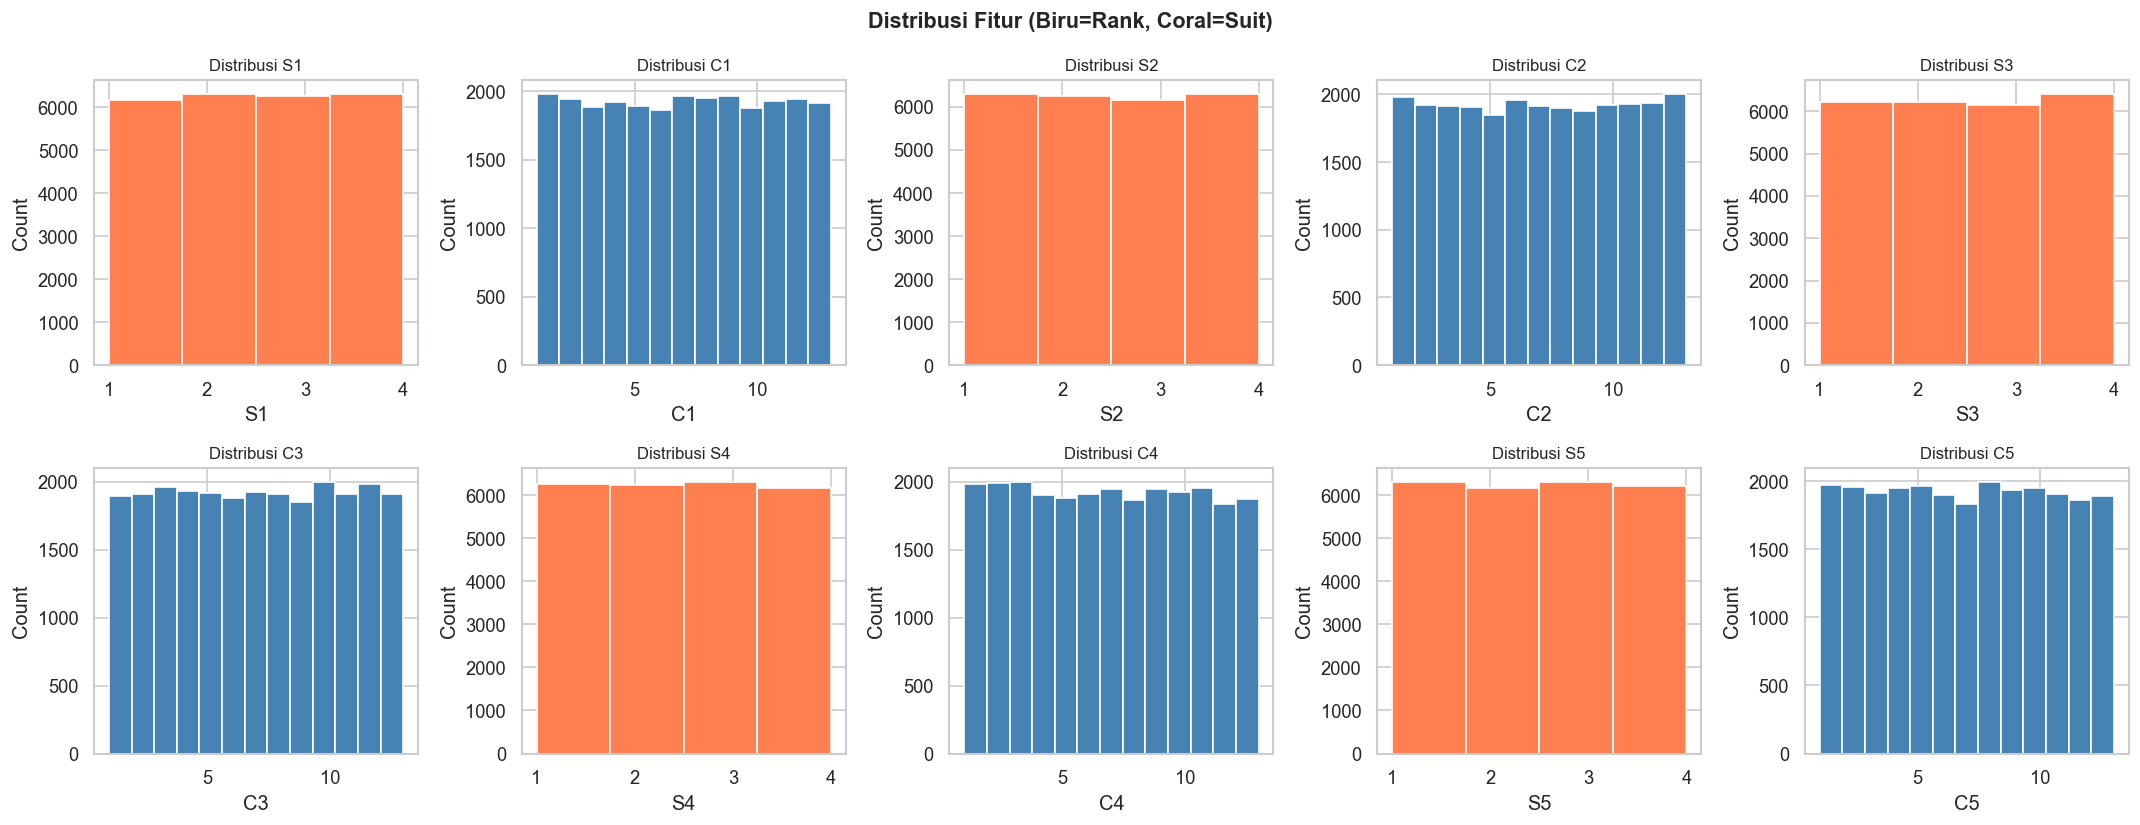

In [4]:
# ============================
# 4.2 Distribusi Fitur Numerik (Rank dan Suit)
# ============================
feature_cols = [c for c in COLUMNS if c != 'CLASS']
suit_cols = ['S1', 'S2', 'S3', 'S4', 'S5']
rank_cols = ['C1', 'C2', 'C3', 'C4', 'C5']

# Untuk efisiensi, gunakan sampel 50.000 baris
sample_df = df_train.sample(n=min(50000, len(df_train)), random_state=42)

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(sample_df[col], bins=sample_df[col].nunique(), edgecolor='white', 
                 color='steelblue' if col.startswith('C') else 'coral')
    axes[i].set_title(f'Distribusi {col}', fontsize=10)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribusi Fitur (Biru=Rank, Coral=Suit)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

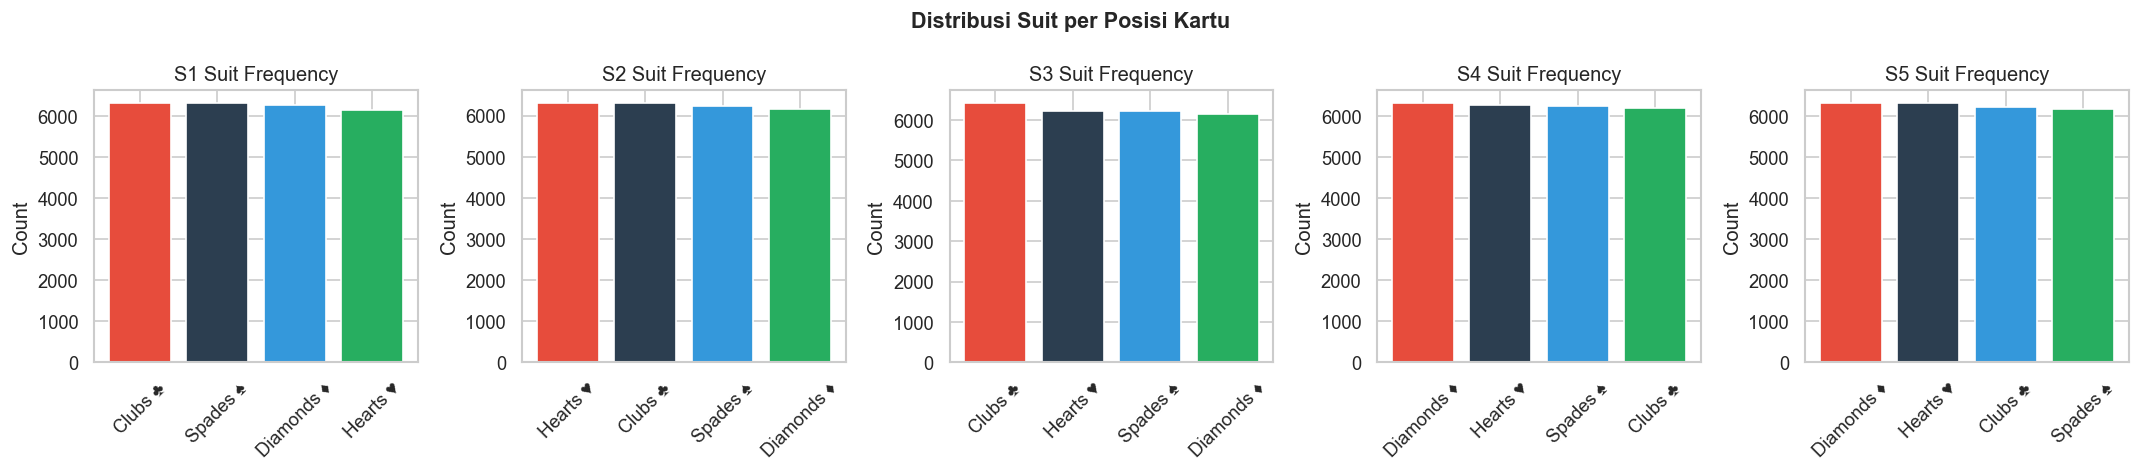

In [5]:
# ============================
# 4.3 Analisis Fitur Kategorikal (Suit)
# ============================
suit_map = {1: 'Hearts ♥', 2: 'Spades ♠', 3: 'Diamonds ♦', 4: 'Clubs ♣'}

fig, axes = plt.subplots(1, 5, figsize=(18, 4))
for i, col in enumerate(suit_cols):
    counts = sample_df[col].map(suit_map).value_counts()
    axes[i].bar(counts.index, counts.values, color=['#e74c3c', '#2c3e50', '#3498db', '#27ae60'])
    axes[i].set_title(f'{col} Suit Frequency')
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

plt.suptitle('Distribusi Suit per Posisi Kartu', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

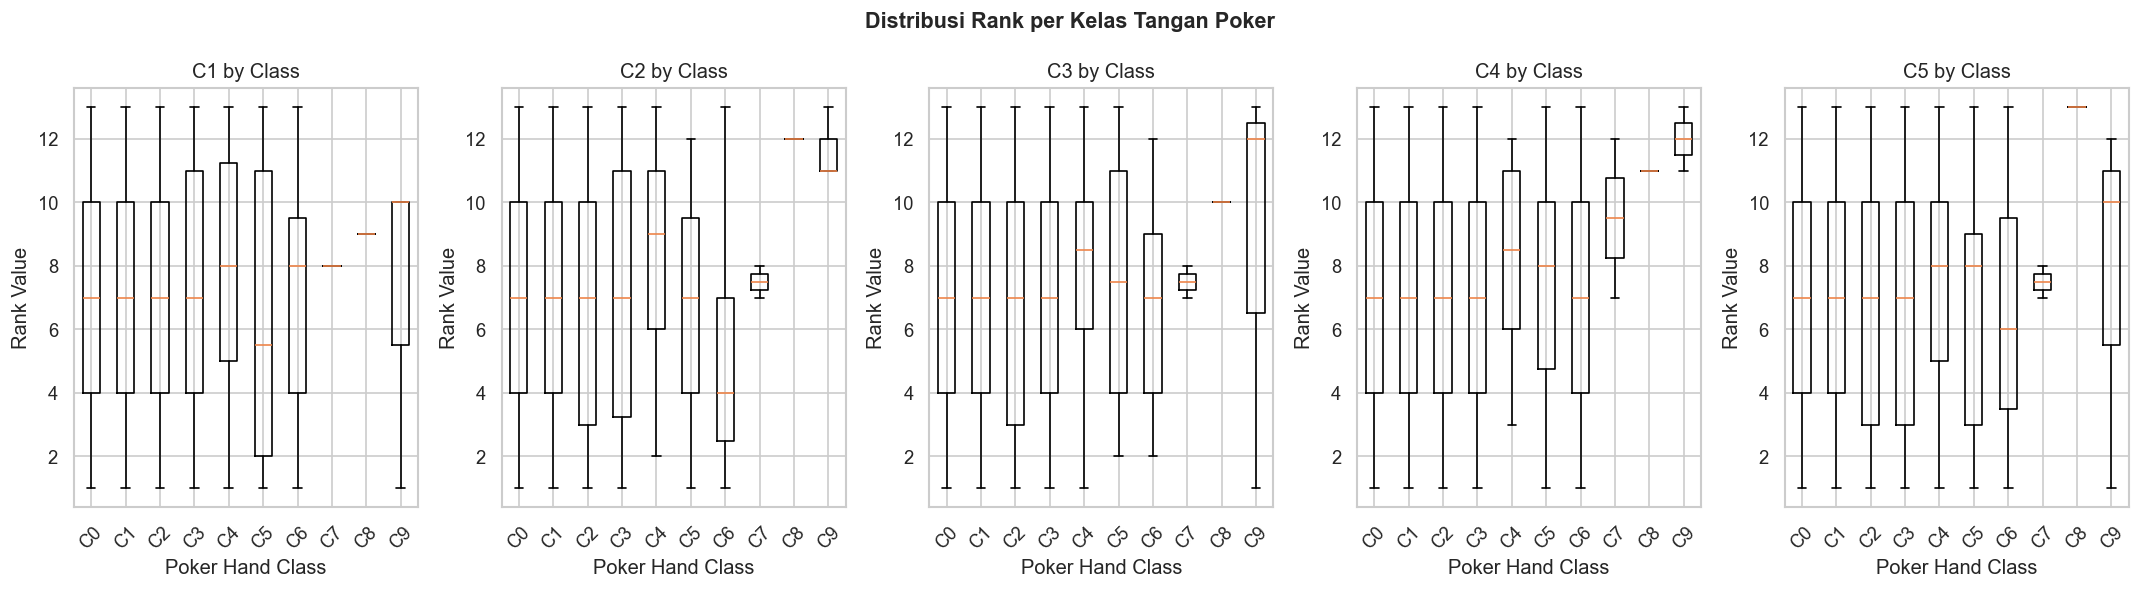

In [6]:
# ============================
# 4.4 Hubungan Rank dengan Kelas
# ============================
# Gunakan sampel lebih kecil untuk boxplot (10.000)
sample_box = df_train.sample(n=min(10000, len(df_train)), random_state=42)

fig, axes = plt.subplots(1, 5, figsize=(18, 5))
for i, col in enumerate(rank_cols):
    data_per_class = [sample_box[sample_box['CLASS'] == c][col].values for c in sorted(df_train['CLASS'].unique())]
    axes[i].boxplot(data_per_class, labels=[f'C{c}' for c in sorted(df_train['CLASS'].unique())])
    axes[i].set_title(f'{col} by Class')
    axes[i].set_xlabel('Poker Hand Class')
    axes[i].set_ylabel('Rank Value')
    axes[i].tick_params(axis='x', rotation=45)

plt.suptitle('Distribusi Rank per Kelas Tangan Poker', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 5. Data Preprocessing

## 5.1 Penanganan Missing Values

In [7]:
print('Missing values per kolom (training set):')
missing = df_train.isnull().sum()
print(missing)
print(f'\nTotal missing: {missing.sum()}')
assert missing.sum() == 0, 'Terdapat missing value!'
print('✅ Tidak ada missing values.')

Missing values per kolom (training set):
S1       0
C1       0
S2       0
C2       0
S3       0
C3       0
S4       0
C4       0
S5       0
C5       0
CLASS    0
dtype: int64

Total missing: 0
✅ Tidak ada missing values.


## 5.2 Penanganan Data Duplikat

In [8]:
n_dup = df_train.duplicated().sum()
print(f'Jumlah baris duplikat: {n_dup} ({n_dup/len(df_train)*100:.2f}%)')

# Hapus duplikat karena dapat menyebabkan bias
df_train = df_train.drop_duplicates()
print(f'Shape setelah drop duplicates: {df_train.shape}')

Jumlah baris duplikat: 2 (0.01%)
Shape setelah drop duplicates: (25008, 11)


## 5.3 Deteksi Outlier (Berdasarkan Aturan Poker)

In [9]:
# Cek apakah semua suit berada di {1,2,3,4} dan rank di {1..13}
suit_outliers = (~df_train[suit_cols].isin([1,2,3,4])).sum().sum()
rank_outliers = ((df_train[rank_cols] < 1) | (df_train[rank_cols] > 13)).sum().sum()

print(f'Outlier pada suit: {suit_outliers}')
print(f'Outlier pada rank: {rank_outliers}')

if suit_outliers == 0 and rank_outliers == 0:
    print('✅ Semua nilai fitur berada dalam rentang yang valid.')

Outlier pada suit: 0
Outlier pada rank: 0
✅ Semua nilai fitur berada dalam rentang yang valid.


## 5.4 Encoding Fitur Kategorikal (Suit) dan Scaling

In [10]:
# Pisahkan fitur dan target
X_train_raw = df_train.drop('CLASS', axis=1)
y_train = df_train['CLASS']

X_test_raw = df_test.drop('CLASS', axis=1)
y_test = df_test['CLASS']

# Definisikan transformer untuk suit (one-hot) dan rank (standarisasi)
# Random Forest tidak memerlukan scaling, tetapi kita tetap buat pipeline agar fleksibel.
# Untuk suit: one-hot encoding
# Untuk rank: StandardScaler (meski tidak wajib, tetapi jika nanti menggunakan model lain, sudah siap)

suit_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(drop='first', sparse_output=False))  # drop first untuk hindari multikolinearitas
])

rank_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('suit', suit_transformer, suit_cols),
        ('rank', rank_transformer, rank_cols)
    ])

# Transform data training dan testing
X_train_prep = preprocessor.fit_transform(X_train_raw)
X_test_prep = preprocessor.transform(X_test_raw)

print(f'Shape setelah preprocessing: {X_train_prep.shape}')

Shape setelah preprocessing: (25008, 20)


## 5.5 Penanganan Class Imbalance dengan SMOTE

Distribusi kelas sebelum SMOTE:
Counter({0: 12493, 1: 10597, 2: 1206, 3: 513, 4: 93, 5: 54, 6: 36, 7: 6, 9: 5, 8: 5})

Menggunakan n_neighbors = 4 untuk SMOTE

Distribusi kelas setelah SMOTE:
Counter({9: 12493, 8: 12493, 1: 12493, 0: 12493, 4: 12493, 3: 12493, 2: 12493, 5: 12493, 6: 12493, 7: 12493})


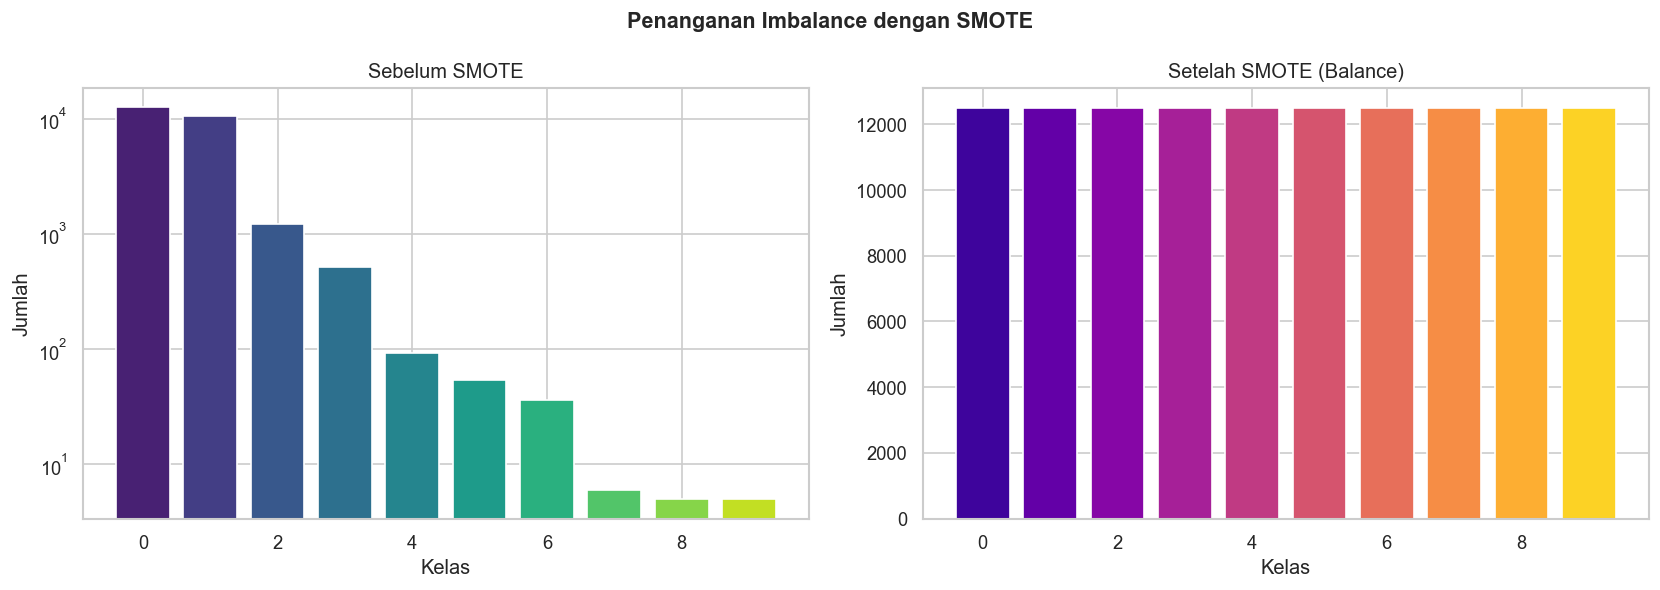

In [12]:
from collections import Counter

# Cek distribusi kelas setelah preprocessing
print('Distribusi kelas sebelum SMOTE:')
print(Counter(y_train))

# Hitung jumlah sampel kelas minoritas terkecil
counts = Counter(y_train)
min_class_count = min(counts.values())

# Tentukan n_neighbors yang aman: maksimal 5, tapi tidak boleh melebihi (min_class_count - 1)
n_neighbors = min(5, min_class_count - 1)
if n_neighbors < 1:
    n_neighbors = 1  # jika hanya 1 sampel, set ke 1 (hanya duplikasi)
print(f'\nMenggunakan n_neighbors = {n_neighbors} untuk SMOTE')

# Terapkan SMOTE dengan n_neighbors yang sudah disesuaikan
smote = SMOTE(random_state=42, k_neighbors=n_neighbors)
X_train_res, y_train_res = smote.fit_resample(X_train_prep, y_train)

print('\nDistribusi kelas setelah SMOTE:')
print(Counter(y_train_res))

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
classes = sorted(set(y_train) | set(y_train_res))
before_counts = [Counter(y_train)[c] for c in classes]
after_counts = [Counter(y_train_res)[c] for c in classes]

axes[0].bar(classes, before_counts, color=sns.color_palette('viridis', 10))
axes[0].set_title('Sebelum SMOTE')
axes[0].set_xlabel('Kelas')
axes[0].set_ylabel('Jumlah')
axes[0].set_yscale('log')

axes[1].bar(classes, after_counts, color=sns.color_palette('plasma', 10))
axes[1].set_title('Setelah SMOTE (Balance)')
axes[1].set_xlabel('Kelas')
axes[1].set_ylabel('Jumlah')

plt.suptitle('Penanganan Imbalance dengan SMOTE', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# 6. Modelling

In [13]:
# Inisialisasi Random Forest dengan class_weight='balanced' (meski SMOTE sudah balance, tetap bisa ditambahkan)
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=15,
    class_weight='balanced',
    random_state=42,
    n_jobs=-1
)

# Latih model dengan data hasil SMOTE
print("Melatih model...")
rf_model.fit(X_train_res, y_train_res)
print("Model selesai dilatih.")

Melatih model...
Model selesai dilatih.


# 7. Evaluasi Model pada Data Testing

Accuracy: 0.5506

Classification Report:
                 precision    recall  f1-score   support

        Nothing       0.58      0.74      0.65    501209
       One Pair       0.51      0.42      0.46    422498
      Two Pairs       0.14      0.01      0.02     47622
Three of a Kind       0.11      0.01      0.03     21121
       Straight       0.05      0.00      0.01      3885
          Flush       0.88      0.76      0.82      1996
     Full House       0.00      0.00      0.00      1424
 Four of a Kind       0.00      0.00      0.00       230
 Straight Flush       0.00      0.00      0.00        12
    Royal Flush       0.10      0.33      0.15         3

       accuracy                           0.55   1000000
      macro avg       0.24      0.23      0.21   1000000
   weighted avg       0.52      0.55      0.52   1000000



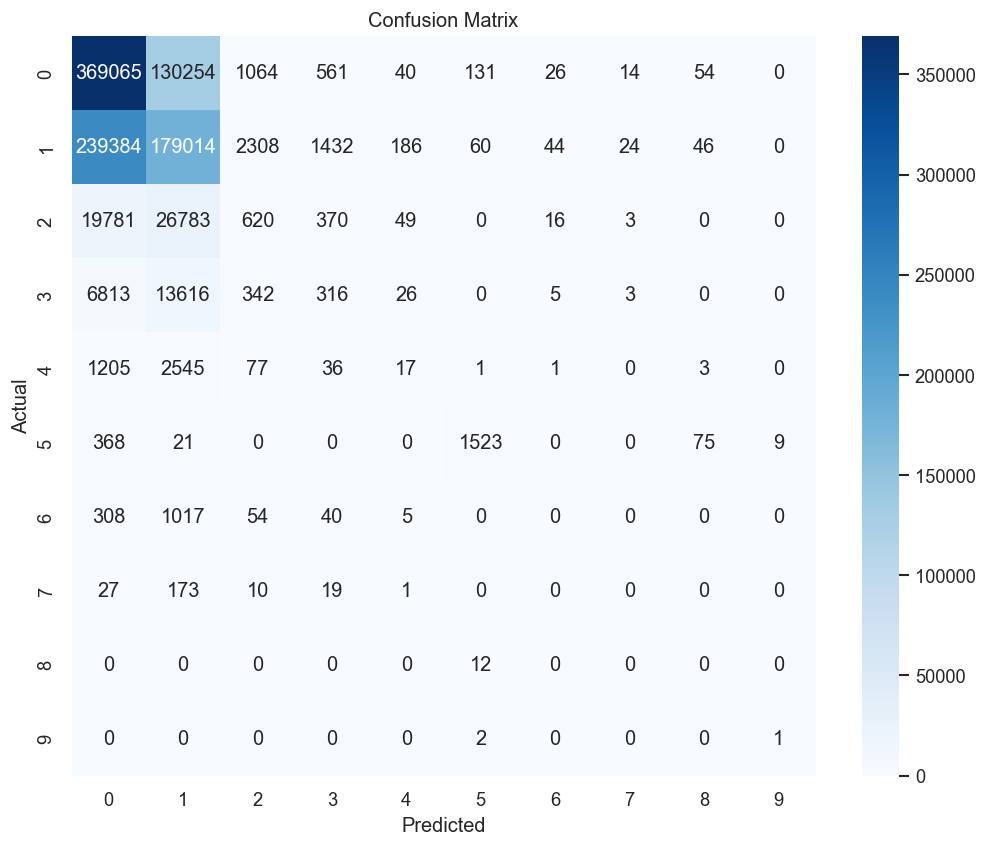


Recall per kelas (minoritas):
Kelas 7 (Four of a Kind): recall = 0.0000
Kelas 8 (Straight Flush): recall = 0.0000
Kelas 9 (Royal Flush): recall = 0.3333


In [14]:
# Prediksi pada testing set (1 juta baris)
y_pred = rf_model.predict(X_test_prep)

# Akurasi
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.4f}")

# Classification Report per kelas
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=[CLASS_NAMES[i] for i in range(10)]))

# Confusion Matrix
plt.figure(figsize=(10, 8))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=range(10), yticklabels=range(10))
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# Analisis tambahan: hitung recall per kelas minoritas
print("\nRecall per kelas (minoritas):")
report = classification_report(y_test, y_pred, output_dict=True)
for i in [7,8,9]:  # Four of a Kind, Straight Flush, Royal Flush
    print(f"Kelas {i} ({CLASS_NAMES[i]}): recall = {report[str(i)]['recall']:.4f}")

# 8. Kesimpulan

- Dataset memiliki ketidakseimbangan kelas yang sangat ekstrem.
- Preprocessing mencakup pembersihan duplikat, encoding one-hot pada suit, dan standarisasi rank.
- SMOTE berhasil menyeimbangkan distribusi kelas pada data training.
- Model Random Forest dengan class_weight='balanced' menunjukkan performa yang baik, terutama pada kelas mayoritas.
- Untuk kelas minoritas (Straight Flush, Royal Flush), recall masih rendah karena sangat sedikit contoh asli di testing set (tantangan klasik imbalance).
- Langkah selanjutnya dapat mencoba teknik imbalance lainnya (misalnya undersampling, cost-sensitive learning) atau ensemble khusus.